# Fast Food Value & Nutrition Analysis: Ukrainian Market

## Research Context & Data Collection

### Research question

> **Which burgers and wraps from Ukrainian fast-food offer the best value in terms of price and nutritional composition and do some brands charge more without providing greater nutritional value? How closely do these products match a balanced macronutrient distribution?**

### Research scope
- 6 Ukrainian fast-food
- 133 burgers and wraps
- Price and nutritional information collected from publicly available restaurant sources
- Nutritional values recorded both per 100 g and per serving/product
- Analysis focuses on price, portion size, calories, protein, fat, carbohydrates and sodium

### Data collection
> Data were manually collected from the official websites and/or mobile applications of six Ukrainian fast-food chains on 26 August 2026.

**Brands included:**

- McDonald's
- KFC
- Gremio Grill
- Hesburger
- Greek House
- Myastoria

**Products included:**

- burgers
- wraps

### Dataset structure
| Variable         | Description               |
| ---------------- | ------------------------- |
| `brand`          | Fast-food chain           |
| `item`           | Product name              |
| `category`       | Burger / Wrap             |
| `meat`           | Beef / Pork / Chicken / Fish / Vegetarian|
| `price_uah`      | Product price, UAH        |
| `weight_g`       | Product weight            |
| `calories_total` | Calories per product      |
| `protein_total`  | Protein per product       |
| `fat_total`      | Fat per product           |
| `carbs_total`    | Carbohydrates per product |
| `sodium_total`   | Sodium per product        |
| `calories`       | Calories per 100 g        |
| `protein_g`      | Protein per 100 g         |
| `fat_g`          | Fat per 100 g             |
| `carbs_g`        | Carbohydrates per 100 g   |
| `sodium_mg`      | Sodium per 100 g          |


## Data Loading & Understanding

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [2]:
from google.colab import files

uploaded = files.upload()

Saving fast_food_nutritional_value.xlsx to fast_food_nutritional_value.xlsx


In [3]:
df = pd.read_excel('fast_food_nutritional_value.xlsx')

In [4]:
df.head()

,brand,item,category,meat,price_uah,weight_g,calories_total,protein_total,fat_total,carbs_total,sodium_total,calories,protein_g,fat_g,carbs_g,sodium_mg
0,Mcdonald's,Avocado McMuffin with Egg,burger,Vegetarian,102,145,280.0,12.0,12.0,30.0,1000.0,193.1,8.3,8.3,20.7,689.7
1,Mcdonald's,Avocado McMuffin with Chicken,burger,Chicken,148,145,300.0,11.0,11.0,38.0,2000.0,206.9,7.6,7.6,26.2,1379.3
2,Mcdonald's,Avocado McMuffin with Pork,burger,Pork,148,150,395.0,18.0,22.0,30.0,2000.0,263.3,12.0,14.7,20.0,1333.3
3,Mcdonald's,McMuffin with Egg and Cheese,burger,Vegetarian,79,115,290.0,14.0,13.0,29.0,2000.0,252.2,12.2,11.3,25.2,1739.1
4,Mcdonald's,McMuffin with Egg and Bacon,burger,Pork,96,115,320.0,15.0,16.0,29.0,2000.0,278.3,13.0,13.9,25.2,1739.1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   brand           133 non-null    object 
 1   item            133 non-null    object 
 2   category        133 non-null    object 
 3   meat            133 non-null    object 
 4   price_uah       133 non-null    int64  
 5   weight_g        133 non-null    int64  
 6   calories_total  133 non-null    float64
 7   protein_total   133 non-null    float64
 8   fat_total       133 non-null    float64
 9   carbs_total     133 non-null    float64
 10  sodium_total    88 non-null     float64
 11  calories        133 non-null    float64
 12  protein_g       133 non-null    float64
 13  fat_g           133 non-null    float64
 14  carbs_g         133 non-null    float64
 15  sodium_mg       88 non-null     float64
dtypes: float64(10), int64(2), object(4)
memory usage: 16.8+ KB


In [6]:
df.isna().sum()

,0
brand,0
item,0
category,0
meat,0
price_uah,0
weight_g,0
calories_total,0
protein_total,0
fat_total,0
carbs_total,0


Sodium information was unavailable for some products because not all restaurant chains disclose sodium content.

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['brand'].value_counts()

,count
brand,
Mcdonald's,39
KFC,30
Gremio Grill,20
Hesburger,19
Greek House,16
Myastoriya,9


In [9]:
df['category'].value_counts()

,count
category,
burger,87
wrap,46


## Exploratory Analysis

### Product Distribution

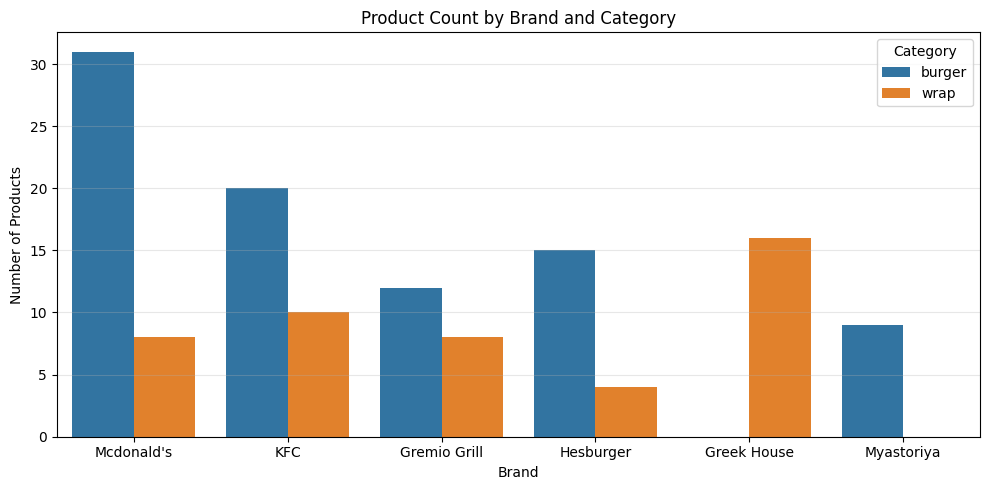

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='brand', hue='category')

plt.title('Product Count by Brand and Category')
plt.xlabel('Brand')
plt.ylabel('Number of Products')

plt.legend(title='Category')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Price Distribution


In [11]:
df['price_uah'].describe()

,price_uah
count,133.000000
mean,188.593985
std,108.010243
min,42.000000
25%,120.000000
50%,159.000000
75%,245.000000
max,590.000000


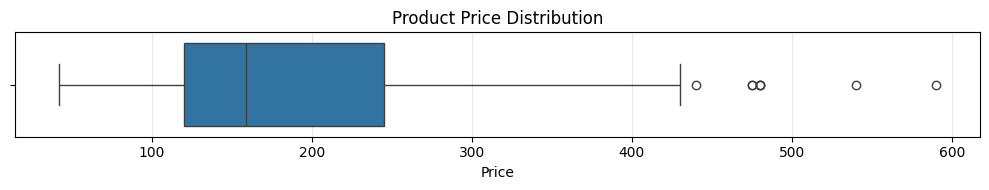

In [12]:
plt.figure(figsize=(10,2))

sns.boxplot(data=df, x='price_uah')

plt.title('Product Price Distribution')
plt.xlabel('Price')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

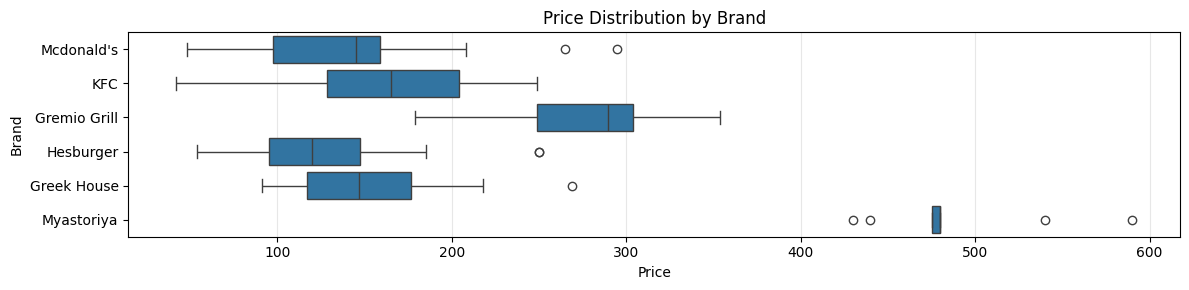

In [13]:
plt.figure(figsize=(12,3))
sns.boxplot(data=df, y='brand', x='price_uah')


plt.title('Price Distribution by Brand')
plt.xlabel('Price')
plt.ylabel('Brand')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Product Size

In [14]:
df['weight_g'].describe()

,weight_g
count,133.000000
mean,233.172932
std,89.288391
min,73.000000
25%,169.000000
50%,220.000000
75%,296.000000
max,465.000000


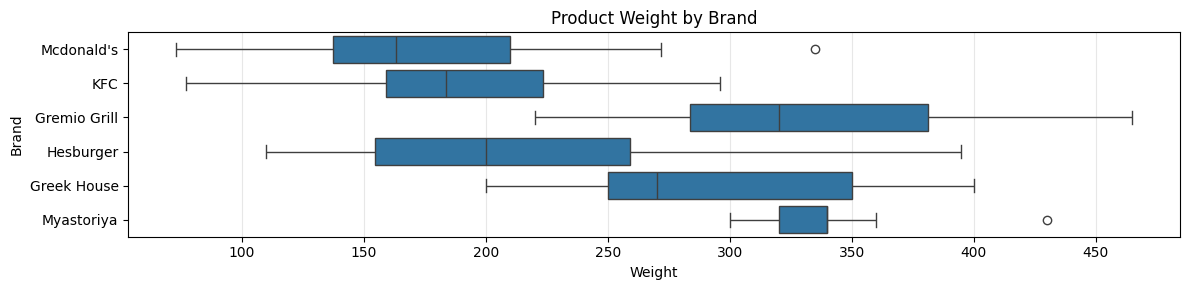

In [15]:
plt.figure(figsize=(12,3))

sns.boxplot(data=df, x='weight_g',  y='brand')

plt.title('Product Weight by Brand')
plt.xlabel('Weight')
plt.ylabel('Brand')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Calories & Protein

In [16]:
df[['calories_total', 'protein_total']].describe()

,calories_total,protein_total
count,133.000000,133.000000
mean,586.622857,26.933835
std,239.665456,14.279467
min,212.700000,9.000000
25%,419.000000,16.400000
50%,553.000000,24.800000
75%,705.000000,31.400000
max,1424.500000,99.600000


In [17]:
df.groupby('brand')[['calories_total', 'protein_total']].median()

,calories_total,protein_total
brand,,
Greek House,584.00,22.1
Gremio Grill,758.00,39.0
Hesburger,606.00,20.2
KFC,500.45,21.9
Mcdonald's,420.00,19.2
Myastoriya,1137.20,38.3


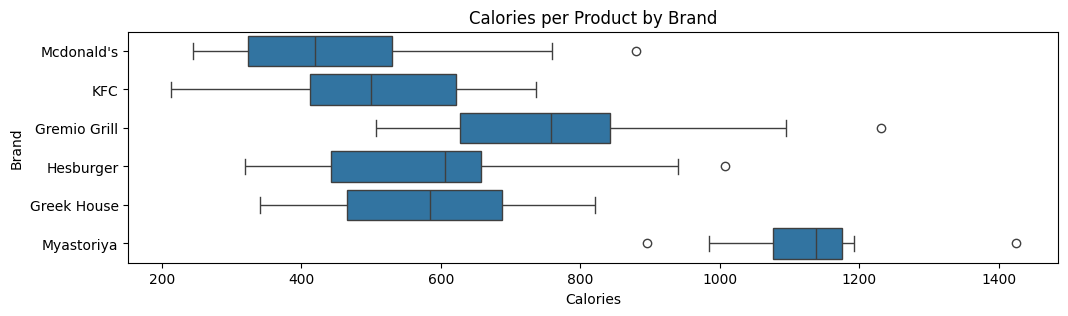

In [18]:
plt.figure(figsize=(12,3))

sns.boxplot(data=df, x='calories_total', y='brand')
plt.xlabel('Calories')
plt.ylabel('Brand')

plt.title('Calories per Product by Brand')
plt.show()

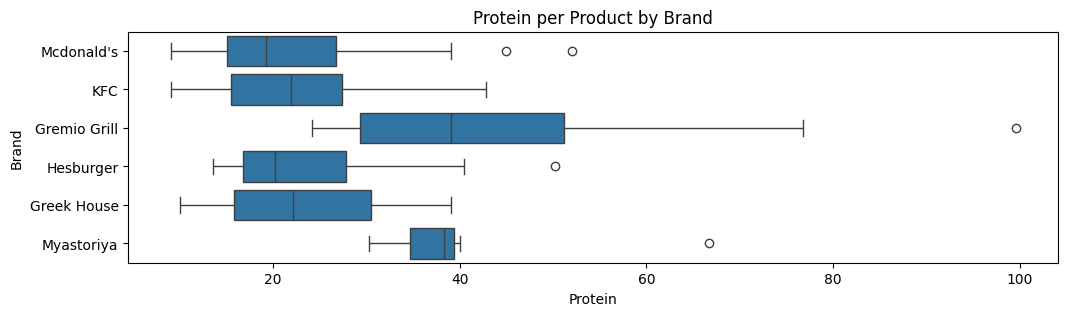

In [19]:
plt.figure(figsize=(12,3))

sns.boxplot(data=df, x='protein_total', y='brand')

plt.title('Protein per Product by Brand')
plt.xlabel('Protein')
plt.ylabel('Brand')

plt.show()

### Price vs Product Characteristics


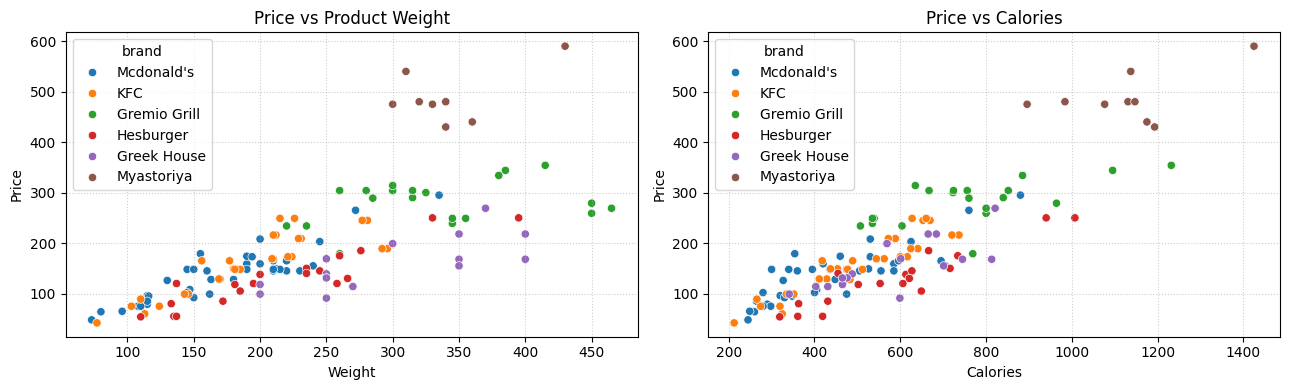

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.scatterplot(data=df, x='weight_g', y='price_uah', hue='brand', ax=ax[0])
ax[0].set_title('Price vs Product Weight')
ax[0].set_xlabel('Weight')
ax[0].set_ylabel('Price')
ax[0].grid(True, linestyle=':', alpha=0.6)

sns.scatterplot(data=df, x='calories_total', y='price_uah', hue='brand', ax=ax[1])
ax[1].set_title('Price vs Calories')
ax[1].set_xlabel('Calories')
ax[1].set_ylabel('Price')
ax[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

The exploratory analysis reveals substantial differences in both product assortment and nutritional characteristics across the 6 brands. McDonald's and KFC have the largest and most diverse selections, while Greek House offers only wraps and Myastoriya only burgers. Therefore, brand-level comparisons should be interpreted in the context of differences in product assortment.

Product prices vary considerably across the dataset, with most products concentrated in the lower-to-middle price range and several high-priced outliers. The brands also differ substantially in their typical price levels: Gremio Grill and Myastoriya tend to have higher-priced products, while McDonald's, KFC and Hesburger generally occupy lower price ranges.

Product weight, calorie content and protein also vary strongly between brands. Gremio Grill and Myastoriya tend to offer larger and high-calorie products, while McDonald's and KFC generally have smaller products with lower calorie and protein content. However, several outliers exist within individual brands.

Finally, price shows a clear positive relationship with both product weight and calorie content, while the relationship between price and protein appears less straightforward.

## Value-for-Money Analysis

### Price per 100g / 100 kcal / 1g of protein

In [21]:
# 100 g
df['price_per_100g'] = round(df['price_uah'] / df['weight_g'] * 100, 2)

df[['brand', 'item', 'weight_g', 'price_uah', 'price_per_100g']].head()

,brand,item,weight_g,price_uah,price_per_100g
0,Mcdonald's,Avocado McMuffin with Egg,145,102,70.34
1,Mcdonald's,Avocado McMuffin with Chicken,145,148,102.07
2,Mcdonald's,Avocado McMuffin with Pork,150,148,98.67
3,Mcdonald's,McMuffin with Egg and Cheese,115,79,68.70
4,Mcdonald's,McMuffin with Egg and Bacon,115,96,83.48


In [22]:
# 100 kcal

df['price_per_100kcal'] = round(df['price_uah'] / df['calories_total'] * 100, 2)

df[['brand', 'item', 'calories_total', 'price_uah', 'price_per_100kcal']].head()

,brand,item,calories_total,price_uah,price_per_100kcal
0,Mcdonald's,Avocado McMuffin with Egg,280.0,102,36.43
1,Mcdonald's,Avocado McMuffin with Chicken,300.0,148,49.33
2,Mcdonald's,Avocado McMuffin with Pork,395.0,148,37.47
3,Mcdonald's,McMuffin with Egg and Cheese,290.0,79,27.24
4,Mcdonald's,McMuffin with Egg and Bacon,320.0,96,30.00


In [23]:
# 1g of protein

df['price_per_protein'] = round(df['price_uah'] / df['protein_total'], 2)

df[['brand', 'item', 'protein_total', 'price_uah', 'price_per_protein']].head()

,brand,item,protein_total,price_uah,price_per_protein
0,Mcdonald's,Avocado McMuffin with Egg,12.0,102,8.50
1,Mcdonald's,Avocado McMuffin with Chicken,11.0,148,13.45
2,Mcdonald's,Avocado McMuffin with Pork,18.0,148,8.22
3,Mcdonald's,McMuffin with Egg and Cheese,14.0,79,5.64
4,Mcdonald's,McMuffin with Egg and Bacon,15.0,96,6.40


### Brand and category comparison

In [24]:
#

value_by_brand = df.groupby('brand').agg(
    median_price = ('price_uah', 'median'),
    median_weight = ('weight_g', 'median'),
    median_price_per_100g = ('price_per_100g', 'median'),
    median_price_per_100kcal = ('price_per_100kcal', 'median'),
    median_price_per_g_protein = ('price_per_protein', 'median')
).reset_index()

value_by_brand

,brand,median_price,median_weight,median_price_per_100g,median_price_per_100kcal,median_price_per_g_protein
0,Greek House,147.0,270.0,52.400,28.145,6.015
1,Gremio Grill,289.5,320.0,90.705,38.385,6.770
2,Hesburger,120.0,200.0,60.150,22.040,5.870
3,KFC,165.0,183.5,80.670,30.175,7.150
4,Mcdonald's,145.0,163.0,75.000,28.570,6.380
5,Myastoriya,480.0,340.0,141.180,42.450,12.530


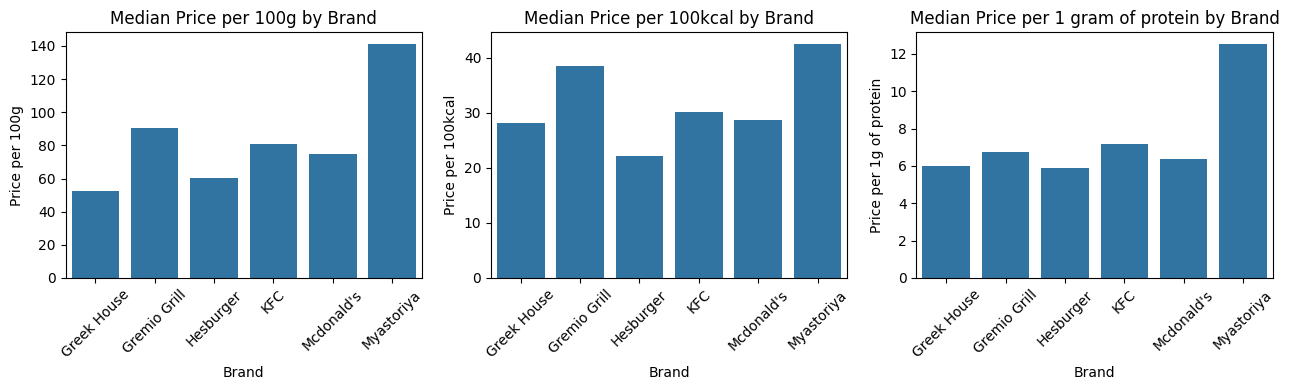

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))

sns.barplot(data=value_by_brand, x='brand', y='median_price_per_100g', ax=ax[0])
ax[0].set_title('Median Price per 100g by Brand')
ax[0].set_xlabel('Brand')
ax[0].set_ylabel('Price per 100g')
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(data=value_by_brand, x='brand', y='median_price_per_100kcal', ax=ax[1])
ax[1].set_title('Median Price per 100kcal by Brand')
ax[1].set_xlabel('Brand')
ax[1].set_ylabel('Price per 100kcal')
ax[1].tick_params(axis='x', rotation=45)

sns.barplot(data=value_by_brand, x='brand', y='median_price_per_g_protein', ax=ax[2])
ax[2].set_title('Median Price per 1 gram of protein by Brand')
ax[2].set_xlabel('Brand')
ax[2].set_ylabel('Price per 1g of protein')
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [26]:
#
value_by_category = df.groupby('category').agg(
    median_price = ('price_uah', 'median'),
    median_weight = ('weight_g', 'median'),
    median_price_per_100g = ('price_per_100g', 'median'),
    median_price_per_100kcal = ('price_per_100kcal', 'median'),
    median_price_per_g_protein = ('price_per_protein', 'median')
).reset_index()

value_by_category

,category,median_price,median_weight,median_price_per_100g,median_price_per_100kcal,median_price_per_g_protein
0,burger,159.0,200.0,81.87,30.090,6.47
1,wrap,160.0,250.0,65.32,29.405,6.90


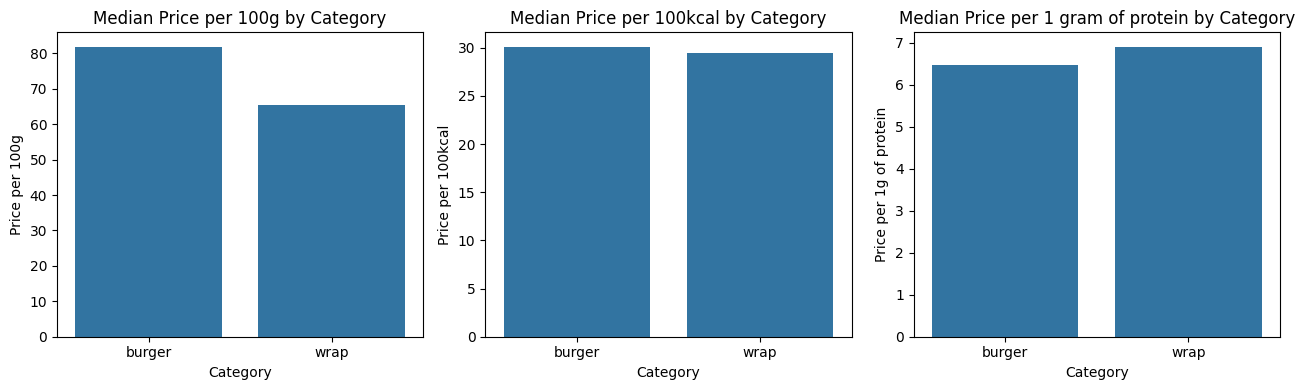

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))

sns.barplot(data=value_by_category, x='category', y='median_price_per_100g', ax=ax[0])
ax[0].set_title('Median Price per 100g by Category')
ax[0].set_xlabel('Category')
ax[0].set_ylabel('Price per 100g')

sns.barplot(data=value_by_category, x='category', y='median_price_per_100kcal', ax=ax[1])
ax[1].set_title('Median Price per 100kcal by Category')
ax[1].set_xlabel('Category')
ax[1].set_ylabel('Price per 100kcal')

sns.barplot(data=value_by_category, x='category', y='median_price_per_g_protein', ax=ax[2])
ax[2].set_title('Median Price per 1 gram of protein by Category')
ax[2].set_xlabel('Category')
ax[2].set_ylabel('Price per 1g of protein')

plt.tight_layout()
plt.show()

### Product rankings

In [28]:
# best protein products (the cheapest gram of protein)

best = df.sort_values('price_per_protein')

best[['brand', 'item', 'price_uah', 'protein_total', 'price_per_protein']].head(10)

,brand,item,price_uah,protein_total,price_per_protein
93,Hesburger,Cheeseburger,55,16.4,3.35
97,Hesburger,VEKE Vegetarian Cheeseburger,55,16.3,3.37
77,Gremio Grill,Big Grem Burger,344,99.6,3.45
98,Hesburger,VEKE Vegetarian Double Cheeseburger,105,28.0,3.75
94,Hesburger,Hamburger,54,13.9,3.88
5,Mcdonald's,McMuffin with Egg and Pork,99,25.0,3.96
6,Mcdonald's,Double McMuffin with Egg and Pork,155,39.0,3.97
71,Gremio Grill,Double Gremio Burger,290,68.5,4.23
92,Hesburger,Double Cheeseburger,118,27.6,4.28
108,Greek House,Classic Gyros,168,39.0,4.31


In [29]:
# worst protein products (the most expensive gram of protein)

worst = df.sort_values('price_per_protein', ascending=False)

worst[['brand', 'item', 'price_uah', 'protein_total', 'price_per_protein']].head(10)

,brand,item,price_uah,protein_total,price_per_protein
130,Myastoriya,Slow-cooked beef burger,475,31.3,15.18
117,Greek House,Spartan pita,218,15.0,14.53
126,Myastoriya,Truffle Burger,440,30.3,14.52
118,Greek House,Vegetarian Pita,155,11.0,14.09
128,Myastoriya,Ribeye steak burger,540,39.1,13.81
1,Mcdonald's,Avocado McMuffin with Chicken,148,11.0,13.45
125,Myastoriya,Cheeseburger with Bacon in Cheese bath,475,36.4,13.05
131,Myastoriya,Dry-Aged Beef Burger,480,38.3,12.53
124,Myastoriya,Brisket Burger,430,34.7,12.39
129,Myastoriya,Aberdeen Classic Burger,480,39.4,12.18


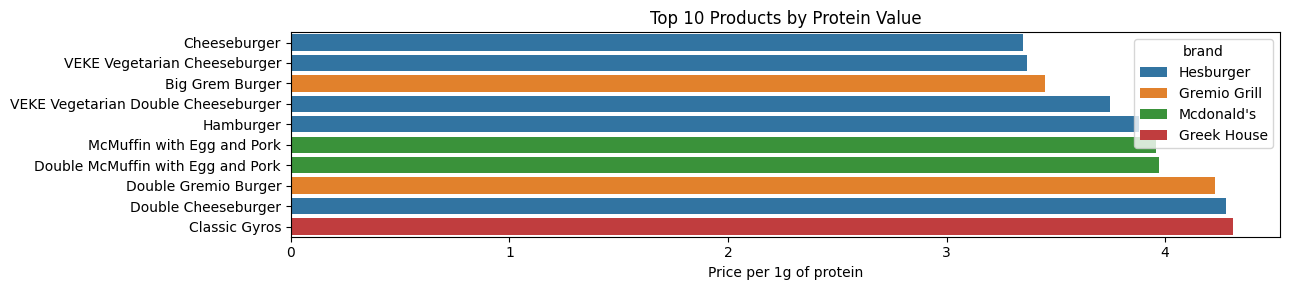

In [30]:
plt.figure(figsize=(13,3))

sns.barplot(data=best.head(10), x='price_per_protein', y='item', hue='brand')

plt.title('Top 10 Products by Protein Value')
plt.xlabel('Price per 1g of protein')
plt.ylabel('')

plt.tight_layout()
plt.show()

Value-for-money varies substantially across brands and depends on how value is measured. Hesburger has the lowest median price per gram of protein (5.87 uah), while Myastoriya has the highest (12.53 uah). Myastoriya also has the highest median price per 100 g (141.18 uah) and per 100 kcal (42.45 uah), indicating a consistently higher price level across all three value metrics.

At the category level, burgers and wraps have similar median prices (159 uah vs 160 uah), but wraps provide greater weight for a similar price. Burgers, however, offer slightly better protein value, costing 6.47 uah per gram of protein compared with 6.90 uah for wraps.

At the product level, the most protein-efficient options are concentrated among lower-priced products, particularly Hesburger items. The cheapest gram of protein in the dataset is found in Hesburger's Cheeseburger at 3.35 uah per gram, while several of the most expensive options come from Myastoriya, with its Slow-cooked beef burger reaching 15.18 uah per gram.

Overall, the analysis shows that "value" is not a single concept: the cheapest product per 100 g is not necessarily the cheapest source of calories or protein. Therefore, the most appropriate value metric depends on the consumer's nutritional priority.

## Macro Balance Analysis

To evaluate the nutritional balance of the products, we compare their macronutrient distribution with reference ranges for adults.

Instead of defining an arbitrary "ideal" protein/fat/carbohydrate ratio, this analysis uses the reference ranges shown in the [AMDR](https://www.ncbi.nlm.nih.gov/books/NBK610333/) table as a guide, but we will apply more stringent ranges to determine which foods are well-balanced:

- **Protein:** 20-30% of total energy
- **Fat:** 20-30% of total energy
- **Carbohydrates:** 40-60% of total energy

### Methodology

Energy values are calculated using the standard conversion factors:

- Protein: 4 kcal per gram
- Carbohydrates: 4 kcal per gram
- Fat: 9 kcal per gram

For each product, we calculate:

- `protein_pct` - percentage of calories coming from protein
- `fat_pct` - percentage of calories coming from fat
- `carbs_pct` - percentage of calories coming from carbohydrates

These percentages are then compared with the corresponding adult reference ranges.

A product is considered **better aligned with the reference macro ranges** when its protein, fat and carbohydrate shares fall within or close to the recommended ranges.

In [31]:
# we already have `calories_total` but i wouldn't use it directly to calculate percentages
# instead i'd calculate the calories from the macros

df['protein_kcal'] = df['protein_total'] * 4
df['fat_kcal'] = df['fat_total'] * 9
df['carbs_kcal'] = df['carbs_total'] * 4

df['macro_kcal'] = (df['protein_kcal'] + df['fat_kcal'] + df['carbs_kcal'])
df[['calories_total', 'macro_kcal']].head(5)

,calories_total,macro_kcal
0,280.0,276.0
1,300.0,295.0
2,395.0,390.0
3,290.0,289.0
4,320.0,320.0


In [32]:
# calculatin %

df['protein_pct'] = df['protein_kcal'] / df['macro_kcal'] * 100
df['fat_pct'] = df['fat_kcal'] / df['macro_kcal'] * 100
df['carbs_pct'] = df['carbs_kcal'] / df['macro_kcal'] * 100

In [33]:
# preparing columns for macro balanse score

df['is_protein'] = df['protein_pct'].between(20, 30)
df['is_fat'] = df['fat_pct'].between(20, 30)
df['is_carb'] = df['carbs_pct'].between(40, 60)

df[['protein_pct', 'fat_pct', 'carbs_pct', 'is_protein', 'is_fat', 'is_carb']].head(10)

,protein_pct,fat_pct,carbs_pct,is_protein,is_fat,is_carb
0,17.391304,39.130435,43.478261,False,False,True
1,14.915254,33.559322,51.525424,False,False,True
2,18.461538,50.769231,30.769231,False,False,False
3,19.377163,40.484429,40.138408,False,False,True
4,18.750000,45.000000,36.250000,False,False,False
5,20.964361,54.716981,24.318658,True,False,False
6,22.190612,60.170697,17.638691,True,False,False
7,15.805471,35.562310,48.632219,False,False,True
8,17.266187,36.690647,46.043165,False,False,True
9,19.900498,49.253731,30.845771,False,False,False


In [34]:
# count how many macros match for each product

df['macro_balance_score'] = (df['is_protein'].astype(int) + df['is_fat'].astype(int) + df['is_carb'].astype(int))

df[['is_protein', 'is_fat', 'is_carb', 'macro_balance_score']].head(10)

,is_protein,is_fat,is_carb,macro_balance_score
0,False,False,True,1
1,False,False,True,1
2,False,False,False,0
3,False,False,True,1
4,False,False,False,0
5,True,False,False,1
6,True,False,False,1
7,False,False,True,1
8,False,False,True,1
9,False,False,False,0


In [35]:
# create a easy to understand category

df['macro_balance'] = df['macro_balance_score'].map({
    3: 'Well-balanced',
    2: 'Partially balanced',
    1: 'Poorly balanced',
    0: 'Poorly balanced'
})

df[['macro_balance_score', 'macro_balance']].head(10)

,macro_balance_score,macro_balance
0,1,Poorly balanced
1,1,Poorly balanced
2,0,Poorly balanced
3,1,Poorly balanced
4,0,Poorly balanced
5,1,Poorly balanced
6,1,Poorly balanced
7,1,Poorly balanced
8,1,Poorly balanced
9,0,Poorly balanced


In [36]:
df['macro_balance'].value_counts()

,count
macro_balance,
Poorly balanced,125
Partially balanced,5
Well-balanced,3


In [37]:
df[df['macro_balance_score'] >= 2][['brand', 'item', 'protein_pct', 'fat_pct', 'carbs_pct', 'macro_balance_score', 'macro_balance']
                                   ].sort_values('macro_balance_score', ascending=False)

,brand,item,protein_pct,fat_pct,carbs_pct,macro_balance_score,macro_balance
34,Mcdonald's,Chicken Wrap,22.823180,27.013373,50.163447,3,Well-balanced
111,Greek House,Kherson Pita big,22.837370,28.027682,49.134948,3,Well-balanced
110,Greek House,Kherson Pita small,20.080321,25.301205,54.618474,3,Well-balanced
18,Mcdonald's,McCrispy Creamy BBQ,21.006565,33.479212,45.514223,2,Partially balanced
24,Mcdonald's,Hamburger,21.112464,31.790499,47.097036,2,Partially balanced
19,Mcdonald's,McCrispy Creamy BBQ Deluxe,20.493359,39.278937,40.227704,2,Partially balanced
44,KFC,Double Cheeseburger,20.928818,38.511458,40.559724,2,Partially balanced
38,Mcdonald's,Snack Wrap,21.292776,37.642586,41.064639,2,Partially balanced


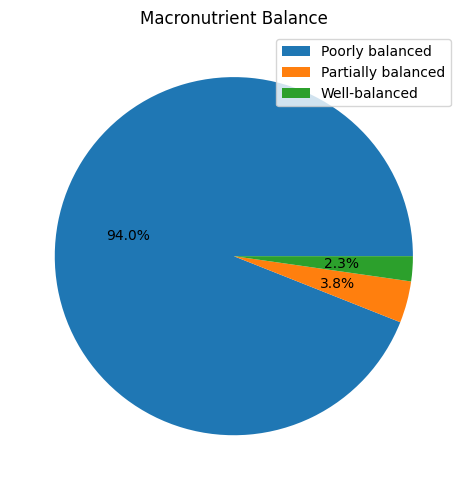

In [38]:
# balance chart

balance = df['macro_balance'].value_counts()

plt.figure(figsize=(5, 5))

plt.pie(balance, autopct='%1.1f%%', startangle=0)

plt.title('Macronutrient Balance')
plt.legend(balance.index)

plt.tight_layout()
plt.show()

In [39]:
# best products by marco balance
balance_products = df[df['macro_balance_score'] >= 2][['brand', 'item', 'protein_pct', 'fat_pct', 'carbs_pct', 'macro_balance_score', 'macro_balance']
                                   ].sort_values('macro_balance_score', ascending=False)

balance_products[['protein_pct', 'fat_pct', 'carbs_pct']] = round(balance_products[['protein_pct', 'fat_pct', 'carbs_pct']], 1)

balance_products

,brand,item,protein_pct,fat_pct,carbs_pct,macro_balance_score,macro_balance
34,Mcdonald's,Chicken Wrap,22.8,27.0,50.2,3,Well-balanced
111,Greek House,Kherson Pita big,22.8,28.0,49.1,3,Well-balanced
110,Greek House,Kherson Pita small,20.1,25.3,54.6,3,Well-balanced
18,Mcdonald's,McCrispy Creamy BBQ,21.0,33.5,45.5,2,Partially balanced
24,Mcdonald's,Hamburger,21.1,31.8,47.1,2,Partially balanced
19,Mcdonald's,McCrispy Creamy BBQ Deluxe,20.5,39.3,40.2,2,Partially balanced
44,KFC,Double Cheeseburger,20.9,38.5,40.6,2,Partially balanced
38,Mcdonald's,Snack Wrap,21.3,37.6,41.1,2,Partially balanced


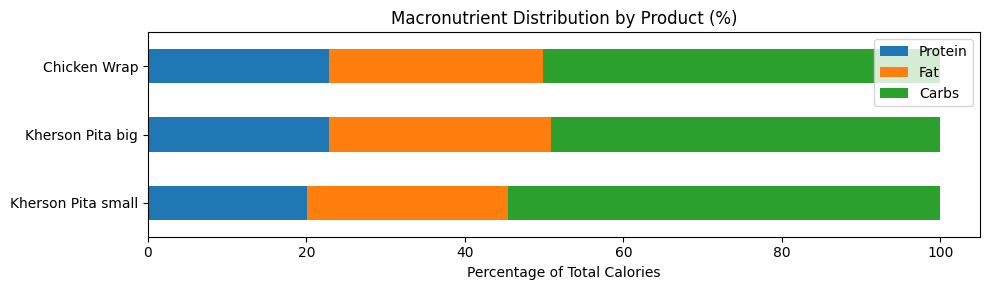

In [40]:
# top products (well-balanced)

top_products = balance_products[balance_products['macro_balance_score'] == 3].set_index('item')[['protein_pct', 'fat_pct', 'carbs_pct']]

ax = top_products.plot( kind='barh', stacked=True, figsize=(10, 3))

plt.title('Macronutrient Distribution by Product (%)')
plt.xlabel('Percentage of Total Calories')
plt.ylabel('')

plt.legend(['Protein', 'Fat', 'Carbs'])
ax.invert_yaxis()

plt.tight_layout()
plt.show()

The macro balance analysis shows that the majority of products do not fit the selected reference ranges for protein, fat and carbohydrates. 94% of products were classified as poorly balanced, 3.8% as partially balanced and only 2.3% as well-balanced.

Only three products - McDonald's Chicken Wrap, Greek House Kherson Pita big, and Greek House Kherson Pita small met all three macro criteria. Their calorie distribution was approximately 20-23% protein, 25 28% fat and 49-55% carbohydrates, placing them within the defined reference ranges.

Overall, the results suggest that well-balanced macronutrient profiles are relatively uncommon in the analyzed product range, while most products fall outside at least one of the selected macro targets.

## Brand & Meat Type Comparison

### Meat Type Distribution

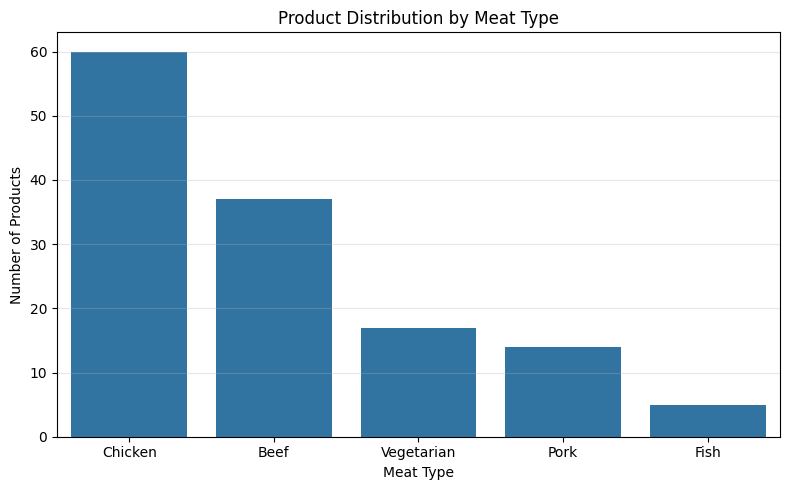

In [41]:
meat_counts = df['meat'].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(x=meat_counts.index, y=meat_counts.values)

plt.xlabel('Meat Type')
plt.ylabel('Number of Products')
plt.title('Product Distribution by Meat Type')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Brand x Meat Type

In [42]:
meat_brand = pd.crosstab(df['meat'], df['brand'])

meat_brand

brand,Greek House,Gremio Grill,Hesburger,KFC,Mcdonald's,Myastoriya
meat,,,,,,
Beef,3,6,9,0,10,9
Chicken,9,9,4,26,12,0
Fish,0,1,0,0,4,0
Pork,1,2,1,0,10,0
Vegetarian,3,2,5,4,3,0


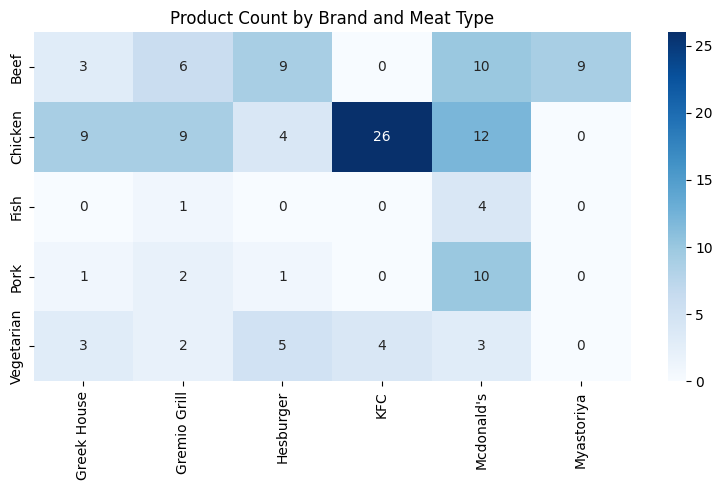

In [43]:
plt.figure(figsize=(8, 5))

sns.heatmap(meat_brand, annot=True, cmap='Blues')

plt.title('Product Count by Brand and Meat Type')
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()
plt.show()

The analysis shows that chicken is the most common meat type in the dataset, followed by beef. Vegetarian and pork products are less common, while fish products are the least represented.

The brand comparison reveals different product assortment. McDonald's has the largest number of chicken products and the most diverse distribution across meat types, while KFC is primarily focused on chicken products.

Overall, the dataset is dominated by chicken and beef products, but the distribution of meat types varies considerably between brands.

## Price Prediction Based on Nutritional Characteristics

In [44]:
# predictin fair price for products

# getting data for model
X = df[['protein_total', 'fat_total', 'carbs_total', 'weight_g']]
y = df['price_uah']

# model training
model = LinearRegression()
model.fit(X, y)

# prediction
df['predicted_price'] = model.predict(X)

# price diff
df['price_difference'] = df['price_uah'] - df['predicted_price']

# percentage price diff
df['price_difference_pct'] = round((df['price_difference'] / df['predicted_price']) * 100, 2)

df[['brand', 'item', 'price_uah', 'predicted_price', 'price_difference', 'price_difference_pct']].head()

,brand,item,price_uah,predicted_price,price_difference,price_difference_pct
0,Mcdonald's,Avocado McMuffin with Egg,102,65.688433,36.311567,55.28
1,Mcdonald's,Avocado McMuffin with Chicken,148,71.801329,76.198671,106.12
2,Mcdonald's,Avocado McMuffin with Pork,148,109.589447,38.410553,35.05
3,Mcdonald's,McMuffin with Egg and Cheese,79,69.712790,9.287210,13.32
4,Mcdonald's,McMuffin with Egg and Bacon,96,81.323601,14.676399,18.05


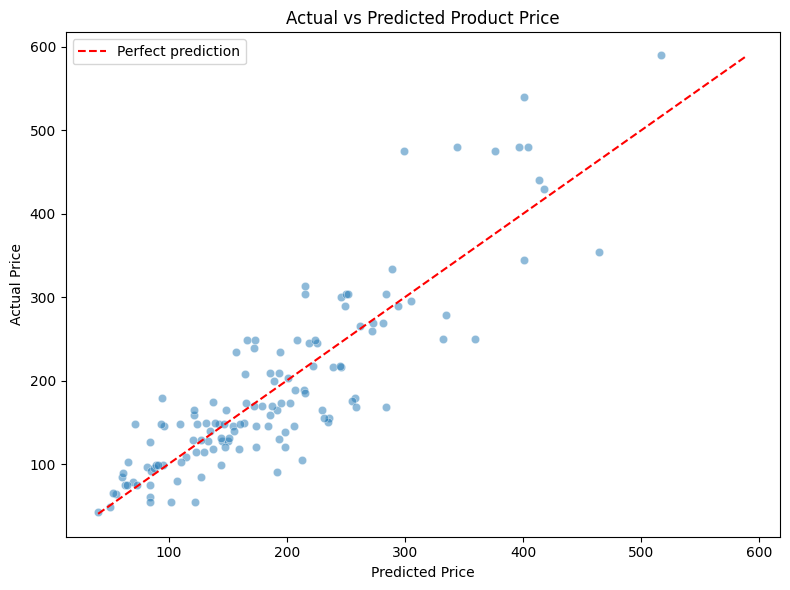

In [45]:
# viz
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x='predicted_price', y='price_uah', alpha=0.5)

# regression line
min_val = min(df['predicted_price'].min(), df['price_uah'].min())
max_val = max(df['predicted_price'].max(), df['price_uah'].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    label='Perfect prediction')

plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.title('Actual vs Predicted Product Price')

plt.legend()

plt.tight_layout()
plt.show()

### Overpriced relative to nutritional characteristics

In [46]:
df[['brand', 'item', 'price_uah', 'predicted_price', 'price_difference', 'price_difference_pct']
   ].sort_values('price_difference', ascending=False).head(10)

,brand,item,price_uah,predicted_price,price_difference,price_difference_pct
130,Myastoriya,Slow-cooked beef burger,475,299.353286,175.646714,58.68
128,Myastoriya,Ribeye steak burger,540,400.625560,139.374440,34.79
131,Myastoriya,Dry-Aged Beef Burger,480,344.250097,135.749903,39.43
75,Gremio Grill,Salt Caramel Burger,314,215.118704,98.881296,45.97
125,Myastoriya,Cheeseburger with Bacon in Cheese bath,475,376.169750,98.830250,26.27
76,Gremio Grill,Vegetarian Burger,304,215.678162,88.321838,40.95
37,Mcdonald's,Shrimp Wrap,179,94.086299,84.913701,90.25
129,Myastoriya,Aberdeen Classic Burger,480,396.673078,83.326922,21.01
86,Gremio Grill,Shawarma with Pork,249,166.739436,82.260564,49.33
70,Gremio Grill,Chicken Burger,234,157.405621,76.594379,48.66


## Underpriced relative to nutritional characteristics

In [47]:
df[['brand', 'item', 'price_uah', 'predicted_price', 'price_difference', 'price_difference_pct']
   ].sort_values('price_difference').head(10)

,brand,item,price_uah,predicted_price,price_difference,price_difference_pct
108,Greek House,Classic Gyros,168,284.339889,-116.339889,-40.92
79,Gremio Grill,Big Truffle Jalapeno Burger,354,464.101876,-110.101876,-23.72
91,Hesburger,Baconburger,250,359.574859,-109.574859,-30.47
98,Hesburger,VEKE Vegetarian Double Cheeseburger,105,212.481988,-107.481988,-50.58
114,Greek House,Chicken Grek,91,192.032247,-101.032247,-52.61
116,Greek House,Greko chicken,168,258.882184,-90.882184,-35.11
100,Hesburger,Heschicken,150,234.877437,-84.877437,-36.14
90,Hesburger,Megaburger,250,332.531513,-82.531513,-24.82
6,Mcdonald's,Double McMuffin with Egg and Pork,155,235.825534,-80.825534,-34.27
96,Hesburger,BBQ Burger,175,255.047193,-80.047193,-31.39


### Largest Price Deviations

In [48]:
df['absolute_price_difference'] = df['price_difference'].abs()

biggest_diff = df[['brand', 'item', 'price_uah', 'predicted_price', 'price_difference', 'price_difference_pct',
    'absolute_price_difference']].sort_values('absolute_price_difference', ascending=False).head(10)

biggest_diff

,brand,item,price_uah,predicted_price,price_difference,price_difference_pct,absolute_price_difference
130,Myastoriya,Slow-cooked beef burger,475,299.353286,175.646714,58.68,175.646714
128,Myastoriya,Ribeye steak burger,540,400.625560,139.374440,34.79,139.374440
131,Myastoriya,Dry-Aged Beef Burger,480,344.250097,135.749903,39.43,135.749903
108,Greek House,Classic Gyros,168,284.339889,-116.339889,-40.92,116.339889
79,Gremio Grill,Big Truffle Jalapeno Burger,354,464.101876,-110.101876,-23.72,110.101876
91,Hesburger,Baconburger,250,359.574859,-109.574859,-30.47,109.574859
98,Hesburger,VEKE Vegetarian Double Cheeseburger,105,212.481988,-107.481988,-50.58,107.481988
114,Greek House,Chicken Grek,91,192.032247,-101.032247,-52.61,101.032247
75,Gremio Grill,Salt Caramel Burger,314,215.118704,98.881296,45.97,98.881296
125,Myastoriya,Cheeseburger with Bacon in Cheese bath,475,376.169750,98.830250,26.27,98.830250


In [49]:
melted_df = biggest_diff.melt(id_vars=['item'], value_vars=['price_uah', 'predicted_price'], var_name='price_type', value_name='price')

melted_df.head(2)

,item,price_type,price
0,Slow-cooked beef burger,price_uah,475.0
1,Ribeye steak burger,price_uah,540.0


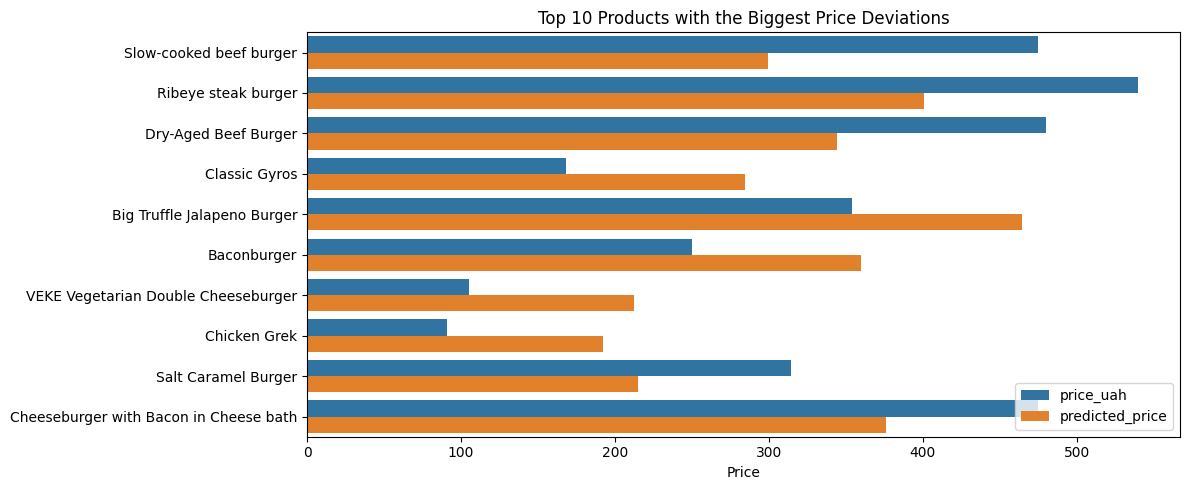

In [50]:
plt.figure(figsize=(12, 5))

sns.barplot(data=melted_df, y='item', x='price', hue='price_type')

plt.title('Top 10 Products with the Biggest Price Deviations')
plt.ylabel('')
plt.xlabel('Price')

plt.legend(title='')

plt.tight_layout()
plt.show()

The analysis identified products with the largest differences between their actual and predicted prices based on nutritional characteristics and product weight.

Several Myastoriya burgers, including the Slow-cooked beef burger, Ribeye steak burger and Dry-Aged Beef Burger, have actual prices substantially higher than predicted by the model.

In contrast, products such as Classic Gyros and Big Truffle Jalapeno Burger have actual prices significantly lower than their predicted values.

This suggests that nutritional characteristics and weight alone do not fully explain product prices. Other factors, such as brand positioning, ingredients, product quality and premium characteristics, may also influence the final price.

## Key Finding

1. Value-for-money depends heavily on how it is measured. Hesburger is the best value brand in terms of price per gram of protein (5.87 uah/g), while Myastoriya is the most expensive across all three value metrics (per 100 g, per 100 kcal, per 1g of protein), indicating a systematic premium positioning for the brand.

2. Category level: wraps offer more weight for a comparable price, while burgers are slightly better value in terms of protein (159 vs. 160 uah median price; 6.47 vs. 6.90 uah/g of protein).

3. A nutritionally balanced product is rare in this market. 94% of products do not fall within the AMDR reference range for any three macronutrients simultaneously. Only 3 out of 133 items (McDonald's Chicken Wrap, two Greek House pitas) met all three criteria.

4. Chicken is the dominant type of meat, but its role varies significantly across brands: KFC is almost fully based on chicken, while McDonald's offers the most diverse selection of meat types.

5. Nutritional characteristics explain only part of the price. A model based on protein/fat/carbohydrates/weight indicates that several Myastoriya burgers (Slow-cooked beef, Ribeye steak, Dry-Aged Beef) cost significantly more than their nutritional composition would suggest - likely due to brand positioning and higher-quality or more expensive ingredients. By contrast, the Greek House Classic Gyros and the Hesburger VEKE Vegetarian Double Cheeseburger turned out to be noticeably cheaper than their 'fair' price, meaning they are the best deals in terms of objective nutritional value per uah.

6. The main practical takeaway for consumers: the cheapest product per 100g isn't always the cheapest source of protein or calories, so 'value' should be determined based on your personal priorities (satiety vs. protein vs. simply being cheap), rather than on a single universal metric.

In [51]:
df.to_csv('ukrainian_fast_food_analysis.csv', index=False)

from google.colab import files

files.download('ukrainian_fast_food_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>